# Oil Trading Analytics
**Markets Covered:** WTI Crude, Brent Crude, RBOB Gasoline, Heating Oil, Natural Gas

This notebook covers:
1. Data acquisition via `yfinance`
2. Price trend analysis
3. Spread analysis (Brent-WTI, 3-2-1 Crack Spread)
4. Correlation matrix across commodities
5. Rolling volatility & returns analysis

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('dark_background')
sns.set_palette('husl')
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#8b949e',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'text.color': '#f0f6fc',
    'font.size': 11
})

COLORS = {
    'WTI':   '#f97316',
    'Brent': '#fb923c',
    'RBOB':  '#38bdf8',
    'HO':    '#818cf8',
    'NG':    '#34d399'
}

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Data

In [2]:
#pip install yfinance
import yfinance as yf

TICKERS = {
    'WTI':   'CL=F',   # WTI Crude Futures
    'Brent': 'BZ=F',   # Brent Crude Futures
    'RBOB':  'RB=F',   # RBOB Gasoline Futures
    'HO':    'HO=F',   # Heating Oil Futures
    'NG':    'NG=F',   # Natural Gas Futures
}

UNITS = {'WTI': '$/bbl', 'Brent': '$/bbl', 'RBOB': '$/gal', 'HO': '$/gal', 'NG': '$/MMBtu'}

raw = yf.download(list(TICKERS.values()), period='1y', auto_adjust=True)['Close']
df = raw.rename(columns={v: k for k, v in TICKERS.items()}).dropna()
print(f'✅ Fetched {len(df)} days of live data')
df.tail()

[*********************100%***********************]  5 of 5 completed

✅ Fetched 252 days of live data


Ticker,Brent,WTI,HO,NG,RBOB
Date,,,,,
2026-03-02,77.739998,71.230003,2.9004,2.960,2.3706
2026-03-03,81.400002,74.559998,3.1869,3.054,2.4574
2026-03-04,81.400002,74.660004,3.2938,2.917,2.5149
2026-03-05,85.410004,81.010002,3.6143,3.003,2.6709
2026-03-06,92.690002,90.900002,3.6224,3.186,2.7466


### Why 1 Year?

**Captures one full seasonal cycle**<br>
Oil markets have strong seasonal patterns — driving season, winter heating demand, refinery maintenance periods. Using exactly 1 year ensures I capture all of these cycles once, giving approximately 252 trading days — sufficient data points for VaR, volatility and correlation statistics to be meaningful. Less than 1 year risks missing entire seasonal periods, giving an incomplete picture. More than 1 year risks including outdated market regimes that no longer reflect current supply and demand dynamics, polluting my analysis.

**Limitation acknowledged**<br>
I understand that a 1-year window captures the current market regime but excludes major crisis periods (2008, 2020). VaR estimates may therefore underestimate true tail risk during black swan events. As my purpose here is to build a general understanding of current oil market conditions, this window is appropriate. A separate stress-testing analysis using 5-10 years of data including crisis periods would complement this work and is something I intend to explore in future projects.

## 3. Summary Statistics

In [3]:
# Summary stats per commodity
summary = pd.DataFrame({
    'Latest Price': df.iloc[-1],
    'Unit': pd.Series(UNITS),
    '1Y High': df.max(),
    '1Y Low': df.min(),
    '1Y Mean': df.mean().round(3),
    'Ann. Volatility (%)': (df.pct_change().std() * np.sqrt(252) * 100).round(2),
    'YTD Return (%)': ((df.iloc[-1] / df.iloc[0] - 1) * 100).round(2)
})

print('=== COMMODITY SUMMARY ===')
summary

=== COMMODITY SUMMARY ===


,Latest Price,Unit,1Y High,1Y Low,1Y Mean,Ann. Volatility (%),YTD Return (%)
Brent,92.690002,$/bbl,92.690002,58.919998,66.847,33.02,31.74
HO,3.622400,$/gal,3.622400,1.974500,2.315,39.87,63.47
NG,3.186000,$/MMBtu,7.460000,2.696000,3.594,98.43,-27.57
RBOB,2.746600,$/gal,2.746600,1.680900,2.018,32.44,30.25
WTI,90.900002,$/bbl,90.900002,55.270000,63.248,36.49,35.59


### Analysis of the table
**Brent and WTI — the crude benchmarks**<br>
Brent at \\$92.69 and WTI at \$90.90 — both ***sitting exactly at their 1 year highs***. This is significant. It means the market has been in a ***sustained uptrend*** and there has been no meaningful pullback recently. The spread between them is \\$1.79 — slightly below the historical norm of \$2-5, suggesting ***US crude is relatively well*** supplied compared to global markets.<br>
Both YTD returns are strong — Brent +31.74% and WTI +35.59%. ***WTI actually outperforming Brent*** is unusual and worth noting — it suggests something specific driving US crude demand or constraining US supply.<br>
***Volatility is moderate*** — Brent at 33.02% and WTI at 36.49%, both within the normal 20-40% range.

**Heating Oil — the standout performer**<br>
HO's YTD return of ***+63.47% is extraordinary*** — nearly double WTI's return. It is also ***sitting at its 1 year high*** of $3.62/gal. Volatility at 39.87% is elevated but not alarming.
This dramatic outperformance of HO versus crude suggests ***refining margins for distillates have been exceptional this year***, which is worth noting.

**RBOB Gasoline**<br>
RBOB at $2.75/gal, ***also at its 1 year high***. Strong but notably weaker than HO — confirming ***distillates have been the dominant story this year*** rather than gasoline. Volatility at 32.44% is the ***lowest of all products***— gasoline demand is ***relatively stable and predictable*** compared to heating oil and natural gas.

**Natural Gas — the outlier**<br>
NG is the only commodity with ***a negative YTD return*** at -27.57%. Everything else is up 30-63% but NG has fallen significantly from its 1 year high of \\$7.46 to the current \\$3.19 — a collapse of 57% from peak. Its current price is below its 1 year mean of \$3.59, meaning the market is currently ***trading below its own annual average***.
Volatility at **98.43% is extreme*** — nearly 3 times higher than crude products and approaching the crisis threshold for oil. However, this is expected and consistent with NG's fundamental market structure. Unlike oil demand which is relatively stable day to day, NG faces a uniquely volatile combination of factors:
- Storage is limited — requiring specialised underground facilities
- Supply can spike suddenly from associated gas production
- Pipelines are difficult and expensive to build, making it a **regional market rather than a global one**
- Price is weather-driven rather than supply-chain driven

These structural characteristics ***mean extreme volatility is not a signal of crisis for NG*** — it is simply the ***nature*** of the market.

## 4. Price History — All Commodities

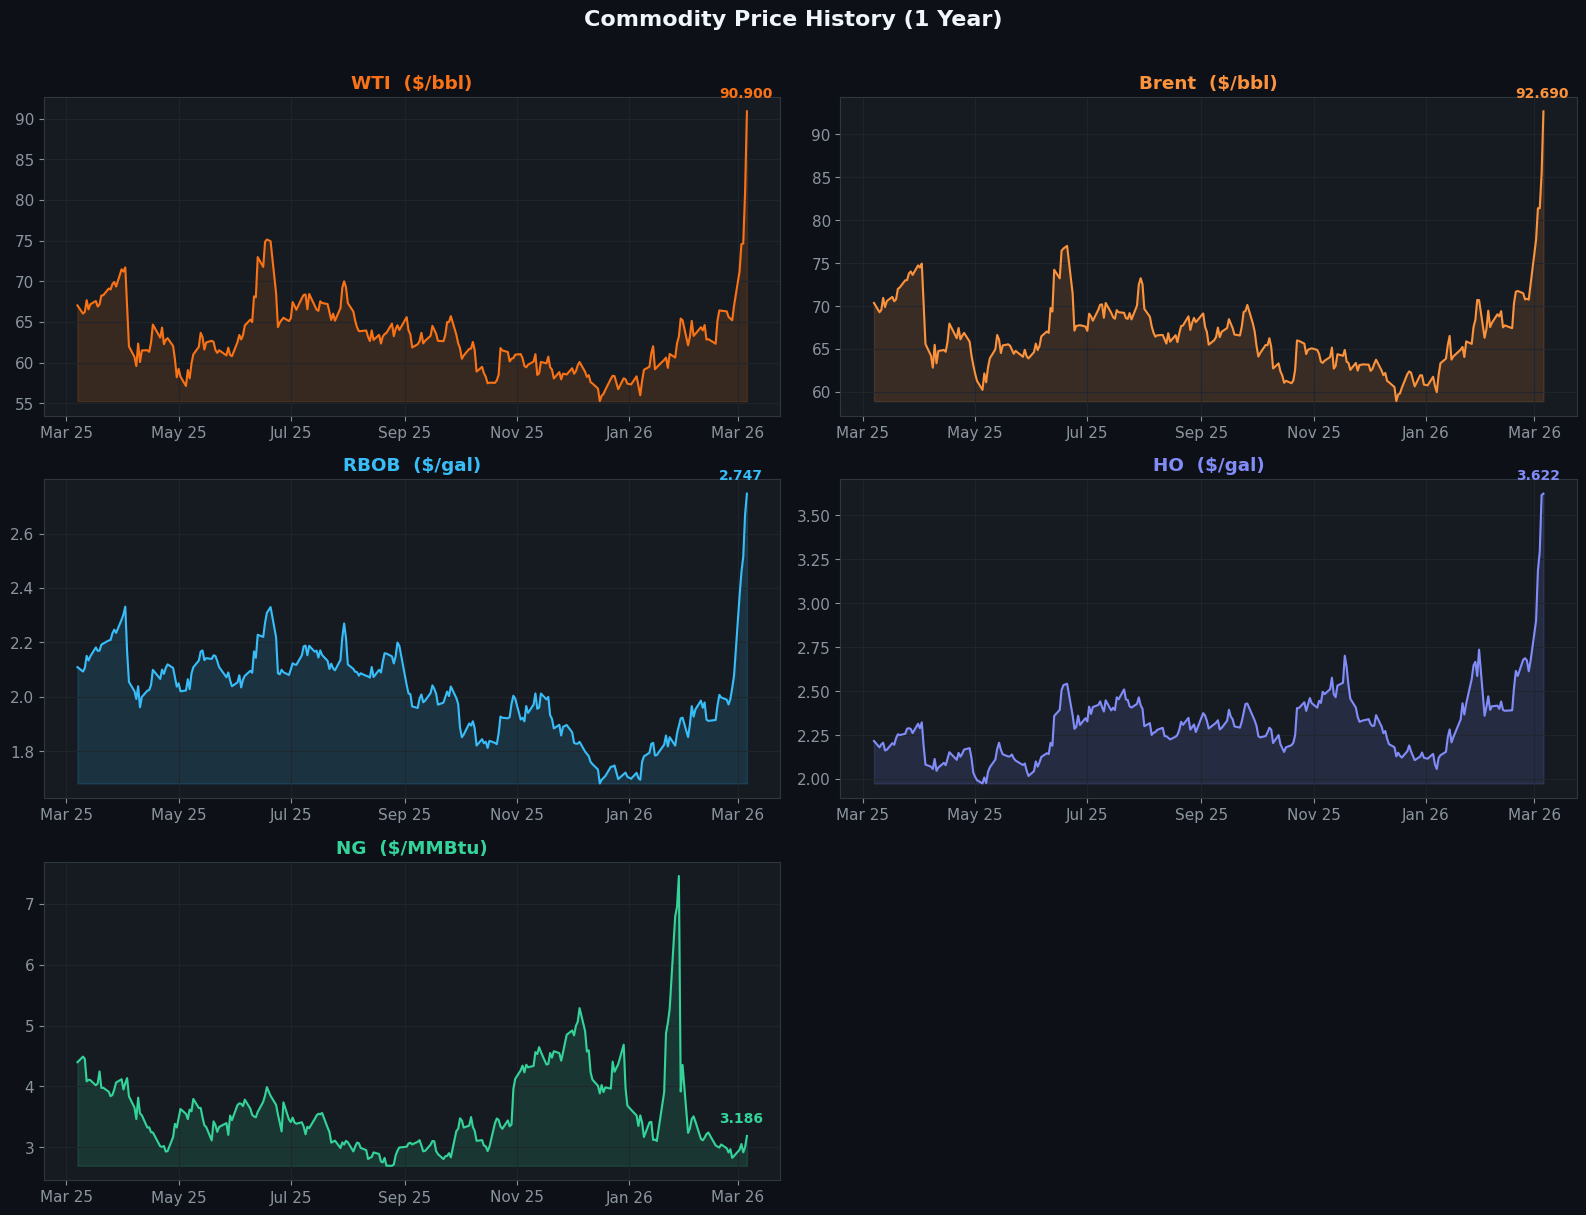

✅ Price history chart created


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Commodity Price History (1 Year)', fontsize=16, fontweight='bold', color='#f0f6fc', y=1.01)

commodities = list(COLORS.keys())
for idx, name in enumerate(commodities):
    ax = axes[idx // 2][idx % 2]
    ax.plot(df.index, df[name], color=COLORS[name], linewidth=1.5)
    ax.fill_between(df.index, df[name], df[name].min(), alpha=0.15, color=COLORS[name])
    ax.set_title(f'{name}  ({UNITS[name]})', color=COLORS[name], fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.grid(True, alpha=0.9)
    # Annotate latest price
    latest = df[name].iloc[-1]
    ax.annotate(f'{latest:.3f}', xy=(df.index[-1], latest),
                xytext=(-20, 10), textcoords='offset points',
                color=COLORS[name], fontsize=10, fontweight='bold')

# Hide last empty subplot
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()
print('✅ Price history chart created')

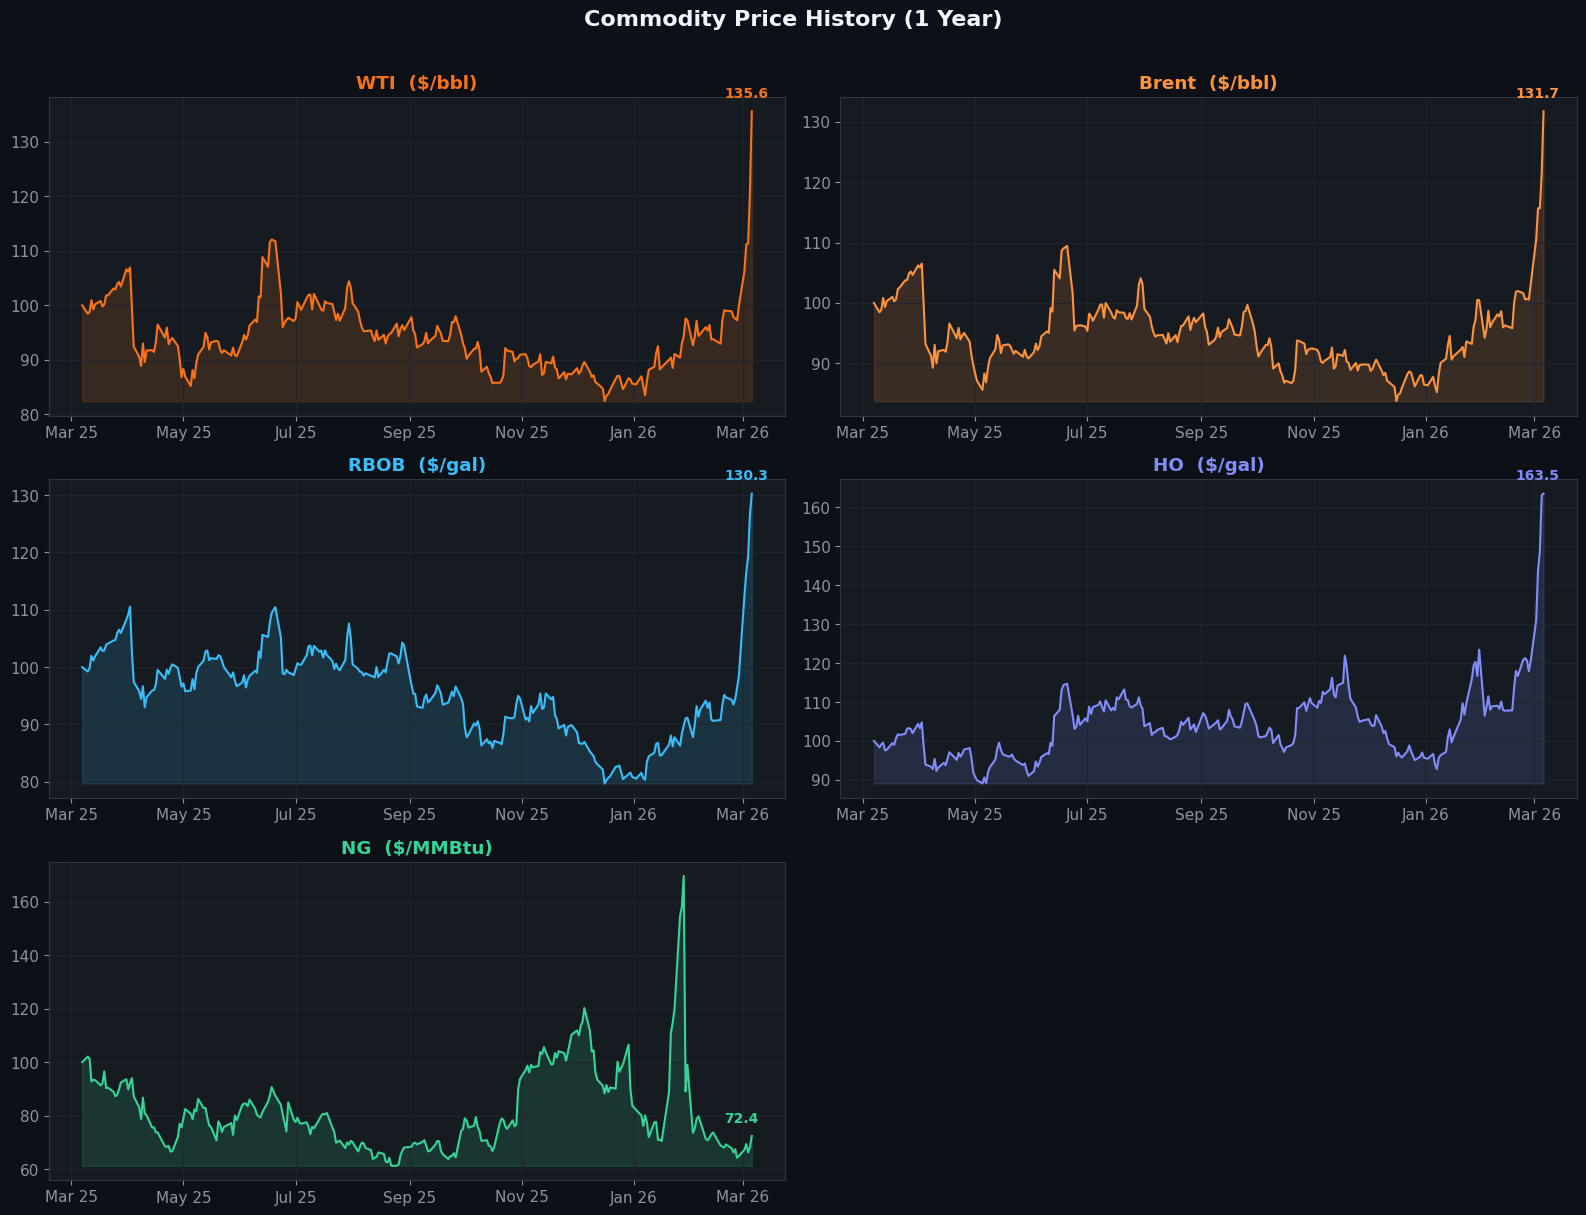

✅ Price history (normalised) chart created


In [5]:
# Normalising data
normalised = df / df.iloc[0] * 100

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Commodity Price History (1 Year)', fontsize=16, fontweight='bold', color='#f0f6fc', y=1.01)

commodities = list(COLORS.keys())
for idx, name in enumerate(commodities):
    ax = axes[idx // 2][idx % 2]
    ax.plot(normalised.index, normalised[name], color=COLORS[name], linewidth=1.5)
    ax.fill_between(normalised.index, normalised[name], normalised[name].min(), alpha=0.15, color=COLORS[name])
    ax.set_title(f'{name}  ({UNITS[name]})', color=COLORS[name], fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.grid(True, alpha=0.9)
    # Annotate latest price
    latest = normalised[name].iloc[-1]
    ax.annotate(f'{latest:.1f}', xy=(normalised.index[-1], latest),
                xytext=(-20, 10), textcoords='offset points',
                color=COLORS[name], fontsize=10, fontweight='bold')

# Hide last empty subplot
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()
print('✅ Price history (normalised) chart created')

### What I Looked Out For

1. **The overall trend — is it going up, down, or sideways?**
   <br>A rising price line over the year means the market has been in a supply deficit — demand exceeded supply. A falling line means oversupply or weak demand. Sideways means balance. This gives me the ***macro story*** before looking at anything  else.

3. **Sharp sudden spikes or crashes**
   <br>Any ***vertical jump or drop*** in the line signals that something happened — an OPEC announcement, a hurricane hitting a refinery, a war escalating. These are the ***moments that require explanation***. I would cross-reference with news for that exact date to connect price movements to real world events.

4. **Do WTI and Brent look the same shape?**
   <br>Since the correlation between WTI and Brent is ~0.97, they should move almost identically. ***If one spikes and the other doesn't***, something ***unusual*** is happening in one specific market — for example, a pipeline burst in the US affecting only WTI while global Brent remains unaffected.

5. **Does Natural Gas look completely different from the others?**
   <br>It should, as NG has a ***very weak correlation*** with WTI and Brent (~0.10), driven by weather and storage rather than oil supply dynamics. If they are moving together, something bigger is happening — such as a broad energy crisis affecting all fuels simultaneously.

6. **The shaded area shape — wide vs narrow**
   <br>This is the reason why I ***normalised*** the data. Without normalisation, it would not be accurate to compare shaded areas across commodities — a 1% move in RBOB or NG is fundamentally different in dollar terms from a 1% move in WTI or Brent due to their different units and price scales. However, I retain the unnormalised chart as well, to preserve a clear view of the actual pricing range for each commodity.
   - A ***wide shaded area*** → large price range over the year → ***high volatility***
   - A ***narrow shaded area*** → tight trading band → ***calm market***
    <br>
7. **Where is the latest price relative to the year's range?**
   <br>The annotated number shows the latest closing price. However, this requires careful interpretation:
   - Price near yearly **high with sustained momentum** → genuinely ***bullish*** — market has been consistently bid higher
   - Price near yearly **high after a sudden spike** → potential blow-off top, reversal risk
   - Price near yearly **low but stabilising** → possible bottoming signal, not necessarily permanently bearish
   - Price near yearly **low and still falling** → ***bearish*** — oversupply or demand destruction ongoing

   Context matters as much as the price level itself.

## 5. Spread Analysis
Spreads are one of the most important signals in oil trading:
- **Brent-WTI**: Measures quality/location premium. Brent is seaborne; WTI is landlocked at Cushing, Oklahoma.
- **3-2-1 Crack Spread**: Proxy for refining margins. Formula: `(2 × RBOB×42 + 1 × HO×42 − 3 × WTI) / 3`

In [6]:
# ── Calculate spreads ─────────────────────────────────────────────────────────
spreads = pd.DataFrame(index=df.index)

# Brent-WTI spread ($/bbl)
spreads['Brent_WTI'] = df['Brent'] - df['WTI']

# 3-2-1 Crack Spread ($/bbl)
# RBOB and HO are in $/gal, multiply by 42 to convert to $/bbl
spreads['Crack_3_2_1'] = (2 * df['RBOB'] * 42 + 1 * df['HO'] * 42 - 3 * df['WTI']) / 3

# HO-RBOB spread (distillate vs gasoline premium)
spreads['HO_RBOB'] = df['HO'] * 42 - df['RBOB'] * 42

# Rolling 30-day average for smoothing
spreads_ma = spreads.rolling(30).mean()

print('=== SPREAD SUMMARY (Latest Values) ===')
print(f"Brent-WTI Spread:   ${spreads['Brent_WTI'].iloc[-1]:.2f}/bbl")
print(f"3-2-1 Crack Spread: ${spreads['Crack_3_2_1'].iloc[-1]:.2f}/bbl")
print(f"HO-RBOB Spread:     ${spreads['HO_RBOB'].iloc[-1]:.2f}/bbl")
spreads.tail()

=== SPREAD SUMMARY (Latest Values) ===
Brent-WTI Spread:   $1.79/bbl
3-2-1 Crack Spread: $36.72/bbl
HO-RBOB Spread:     $36.78/bbl


,Brent_WTI,Crack_3_2_1,HO_RBOB
Date,,,
2026-03-02,6.509995,35.752395,22.251597
2026-03-03,6.840004,38.863803,30.638992
2026-03-04,6.739998,41.870397,32.713806
2026-03-05,4.400002,44.375401,39.622796
2026-03-06,1.790001,36.718397,36.783606


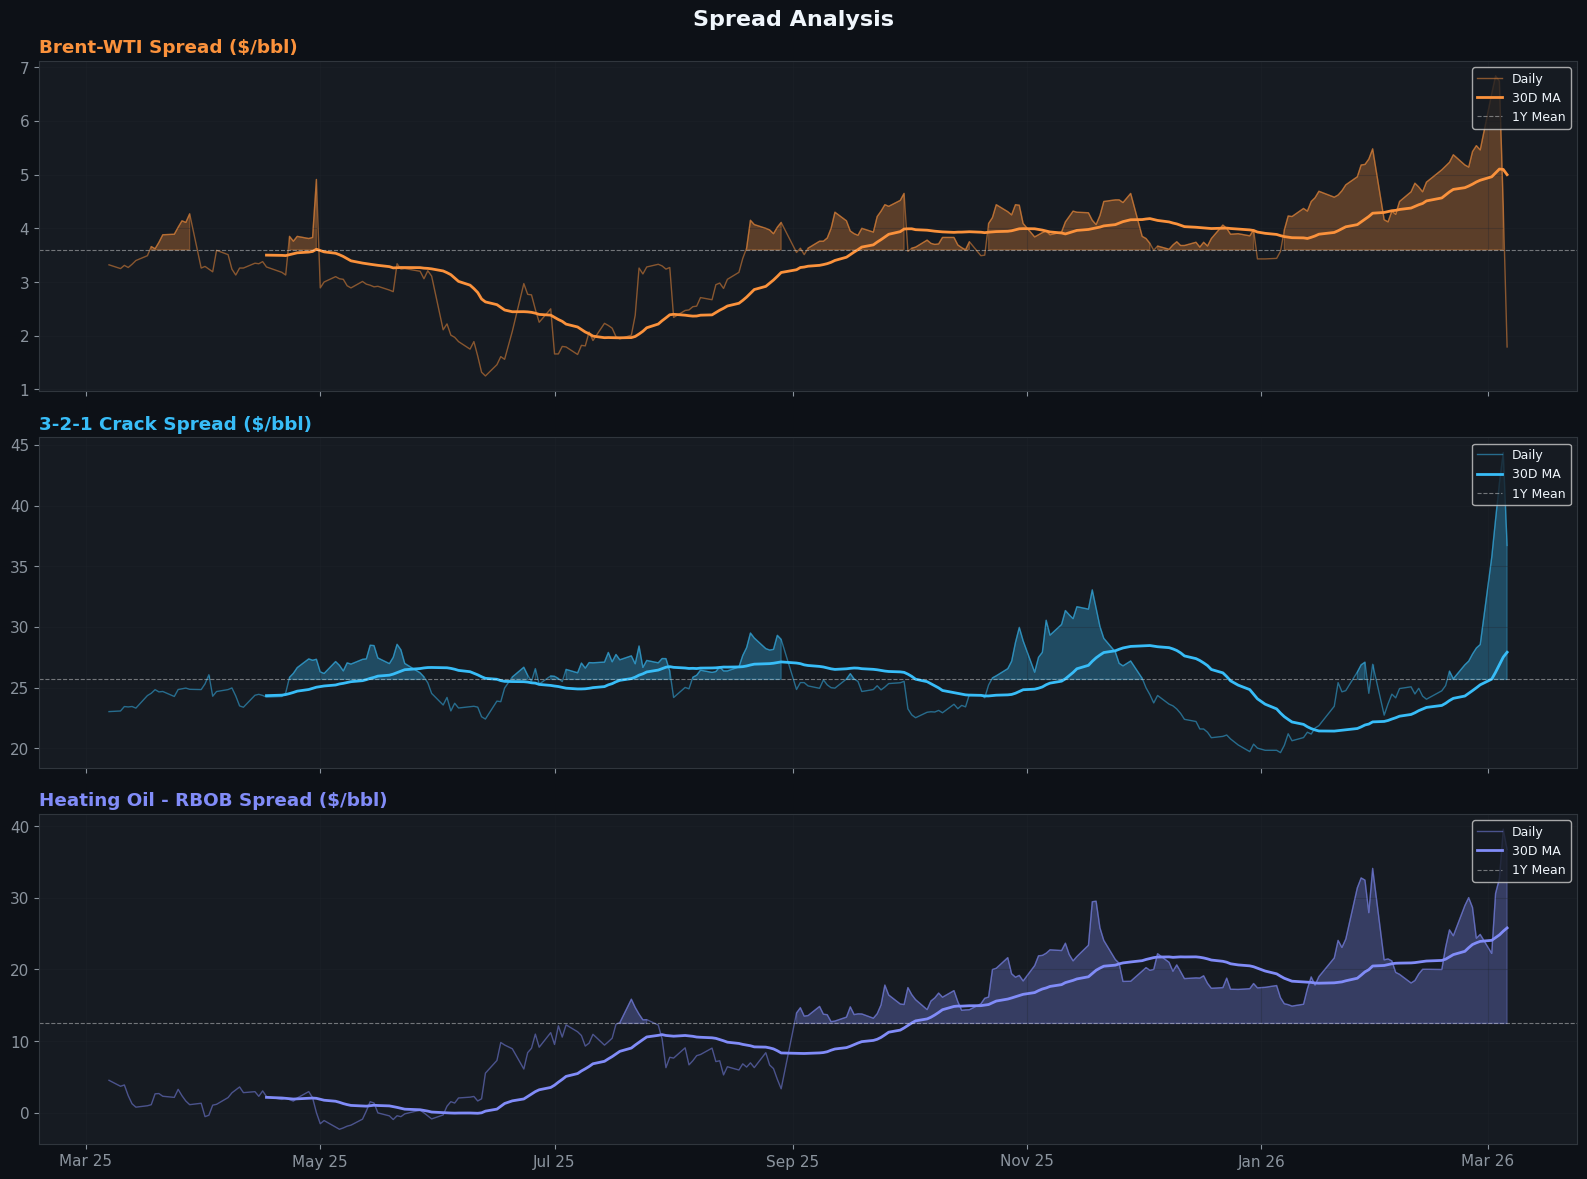

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Spread Analysis', fontsize=16, fontweight='bold', color='#f0f6fc')

spread_config = [
    ('Brent_WTI',   'Brent-WTI Spread ($/bbl)',          '#fb923c'),
    ('Crack_3_2_1', '3-2-1 Crack Spread ($/bbl)',         '#38bdf8'),
    ('HO_RBOB',     'Heating Oil - RBOB Spread ($/bbl)',  '#818cf8'),
]

for ax, (col, title, color) in zip(axes, spread_config):
    ax.plot(spreads.index, spreads[col], color=color, linewidth=1, alpha=0.5, label='Daily')
    ax.plot(spreads_ma.index, spreads_ma[col], color=color, linewidth=2, label='30D MA')
    ax.axhline(y=spreads[col].mean(), color='white', linestyle='--', linewidth=0.8, alpha=0.4, label='1Y Mean')
    ax.fill_between(spreads.index, spreads[col], spreads[col].mean(),
                    where=spreads[col] > spreads[col].mean(), alpha=0.3, color=color)
    ax.set_title(title, color=color, fontweight='bold', loc='left')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.tight_layout()
plt.show()

### Purpose of Each Spread

**Brent-WTI Spread**
Brent almost always trades higher than WTI due to its global accessibility — it loads directly onto ships and can reach any market worldwide, while WTI is landlocked at Cushing, Oklahoma, and can only move via pipelines.

- **Normal result** (\\$2 to \$5) — ***healthy market***, Brent at a small premium reflecting its logistical advantage
- **Wide spread** (>\$10) — something specific is ***pressuring WTI down***, such as US storage filling up, pipeline bottlenecks, or a surge in US shale production that cannot be exported fast enough
- **Negative spread** (WTI > Brent) — unusual, signals something ***disrupting Brent supply specifically***, such as North Sea maintenance shutdowns or geopolitical tension in Europe

**3-2-1 Crack Spread**
This measures ***refinery profitability***. It is one of the most closely watched metrics in oil trading because refinery margins directly influence how much crude oil refineries will buy — making it a ***leading indicator*** for crude demand.

- **Below \$5/bbl** — refineries barely ***breaking even***, some may slow production or shut down, ***reducing crude demand***
- **\$5 to \$15/bbl** — ***normal healthy margins***, refineries running comfortably
- **\$15 to \$25/bbl** — ***strong margins***, refineries running at full capacity, ***buying maximum crude***
- **Above \$25/bbl** — ***exceptional margins***, very strong product demand outpacing crude supply
- **Negative** — refineries losing money on every barrel, extremely rare butsignals severe market dislocation

A ***widening crack spread*** is ***bullish*** for crude prices — profitable refineries buy more crude. A ***collapsing crack spread*** is ***bearish*** — refineries slow down and reduce crude purchases.

**Heating Oil - RBOB Spread**
This measures which ***refined product commands a premium*** at any given moment — diesel/heating oil versus gasoline. Since both come from the same crude oil, the spread reveals which end of the demand spectrum is stronger.

- Positive spread- **HO premium rising**
- Negative spread- **RBOB premium rising**

HO/ distillates is needed almost every part of the economy. Thus it is often used as a ***better indicator of overall economic health*** than gasoline (RBOB). A rising HO premium often signals strong economic growth; a falling HO premium can be an early warning of economic slowdown — sometimes visible in energy data ***before it appears in official GDP figures***.

## 6. Correlation Matrix
Understanding how commodities move together is essential for risk management and hedging decisions.

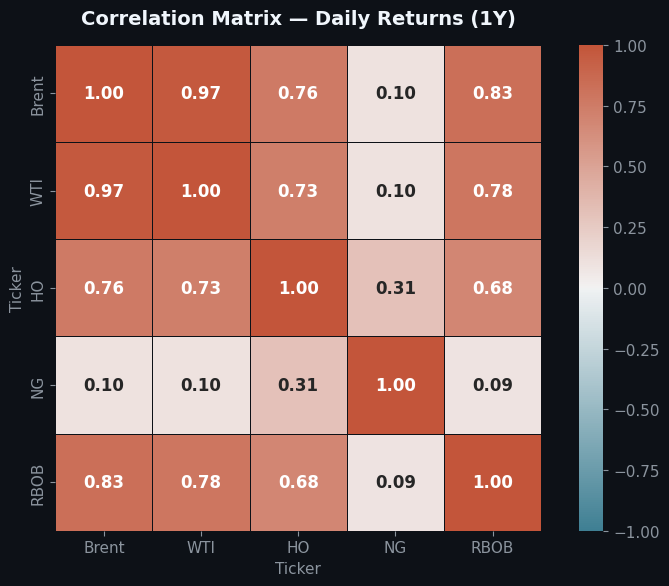


=== KEY OBSERVATIONS ===
WTI-Brent correlation:  0.972  (expected ~0.97 — same crude benchmark)
WTI-RBOB correlation:   0.782  (expected ~0.85 — refined product follows crude)
WTI-NG correlation:     0.101   (expected low — different supply drivers)


In [8]:
# Correlation on daily returns (not prices — to avoid spurious correlation)
returns = df.pct_change().dropna()
corr = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Show only lower triangle

sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
    linecolor='#0d1117',
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Correlation Matrix — Daily Returns (1Y)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== KEY OBSERVATIONS ===')
print(f"WTI-Brent correlation:  {corr.loc['WTI','Brent']:.3f}  (expected ~0.97 — same crude benchmark)")
print(f"WTI-RBOB correlation:   {corr.loc['WTI','RBOB']:.3f}  (expected ~0.85 — refined product follows crude)")
print(f"WTI-NG correlation:     {corr.loc['WTI','NG']:.3f}   (expected low — different supply drivers)")

## 7. Rolling Volatility & Returns Distribution

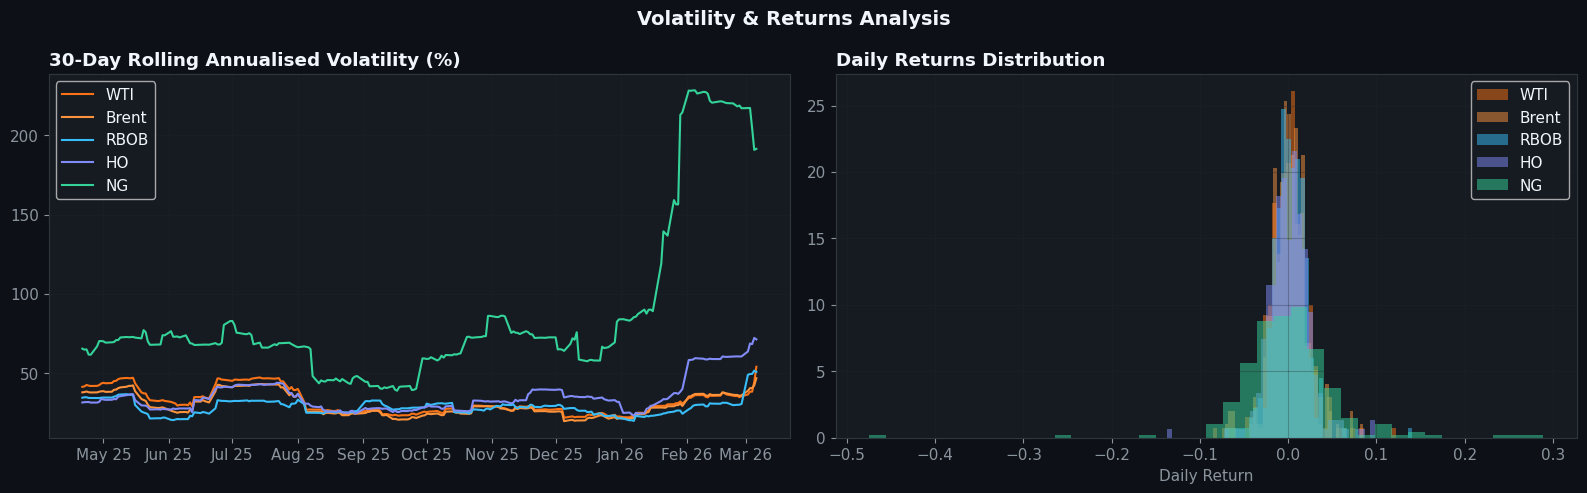

In [9]:
# Rolling 30-day annualised volatility
rolling_vol = returns.rolling(30).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Volatility & Returns Analysis', fontsize=14, fontweight='bold')

# Left: Rolling volatility
for name, color in COLORS.items():
    axes[0].plot(rolling_vol.index, rolling_vol[name], label=name, color=color, linewidth=1.5)
axes[0].set_title('30-Day Rolling Annualised Volatility (%)', fontweight='bold', loc='left')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

# Right: Return distributions
for name, color in COLORS.items():
    axes[1].hist(returns[name].dropna(), bins=40, alpha=0.5, label=name, color=color, density=True)
axes[1].set_title('Daily Returns Distribution', fontweight='bold', loc='left')
axes[1].set_xlabel('Daily Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

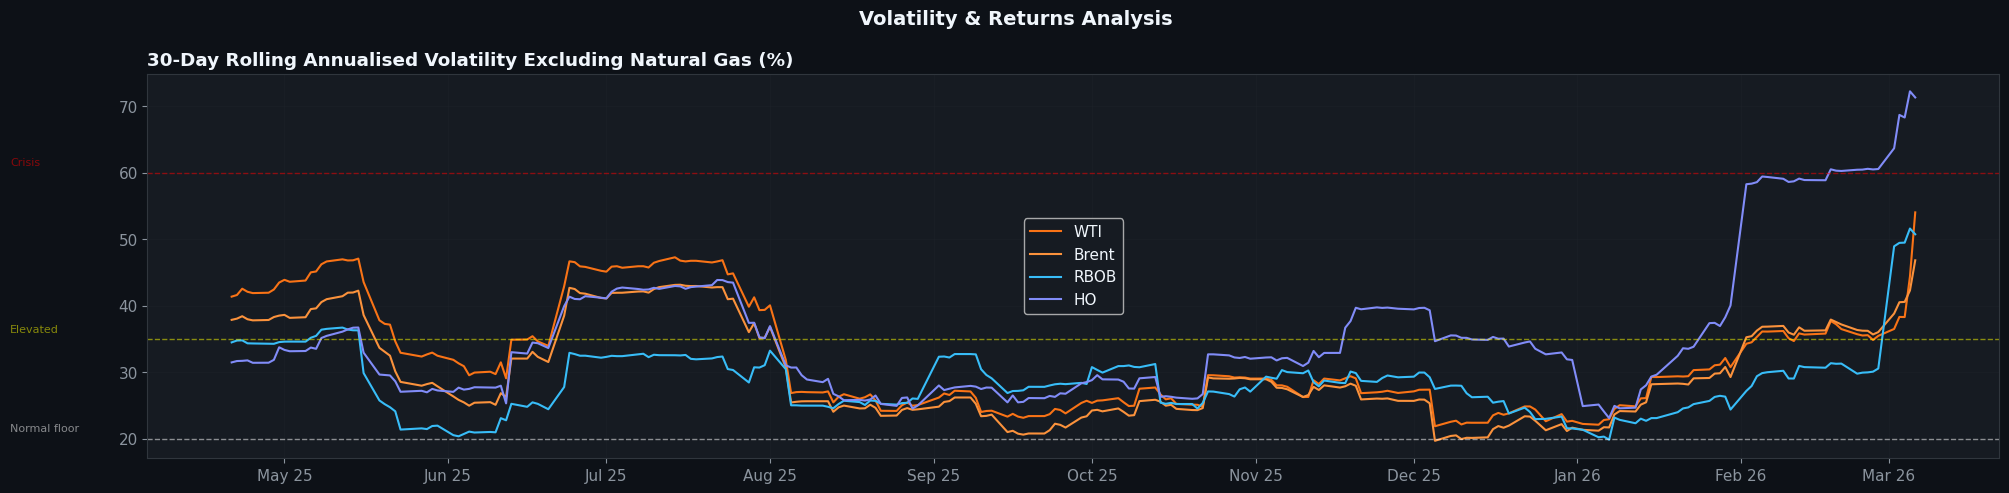

In [10]:
# Excluding NG
crude_products = ['WTI', 'Brent', 'RBOB', 'HO']

fig, ax = plt.subplots(1, 1, figsize=(20, 5))
fig.suptitle('Volatility & Returns Analysis', fontsize=14, fontweight='bold')

# Left: Rolling volatility
for name in crude_products:
    ax.plot(rolling_vol.index, rolling_vol[name], label=name, color=COLORS[name], linewidth=1.5)

benchmarks = [
    (20, 'Normal floor',  'white'),
    (35, 'Elevated',      'yellow'),
    (60, 'Crisis',        'red'),
]

for level, label, color in benchmarks:
    ax.axhline(y=level, color=color, linestyle='--', linewidth=1.0, alpha=0.5)
    ax.text(rolling_vol.index[0], level + 1, label, 
            color=color, fontsize=8, alpha=0.5)

ax.set_title('30-Day Rolling Annualised Volatility Excluding Natural Gas (%)', fontweight='bold', loc='left')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

plt.tight_layout()
plt.show()

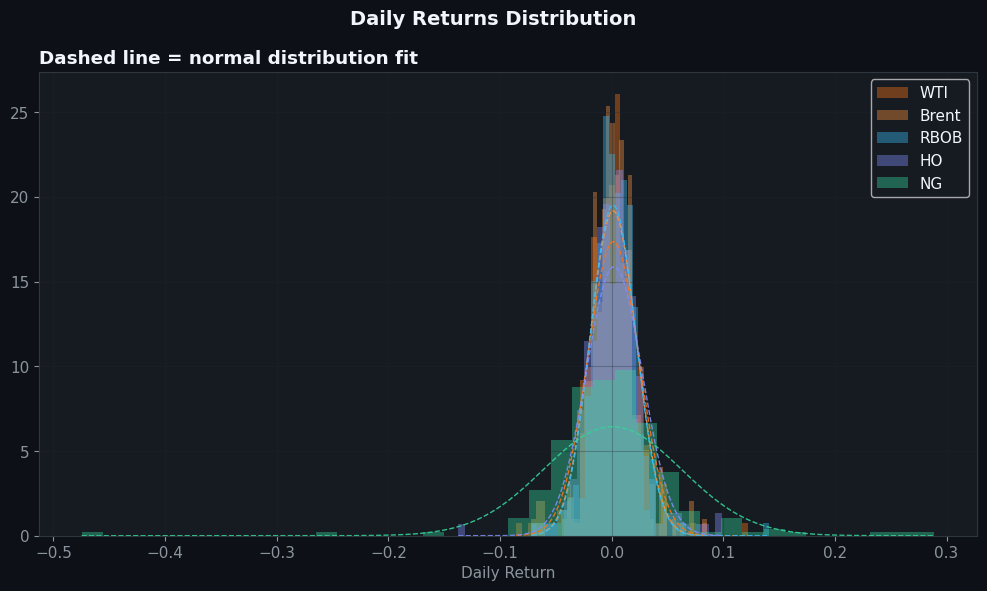

In [11]:
# Analysing of returns distribution
#!pip install spicy
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('Daily Returns Distribution', fontsize=14, fontweight='bold')

for name, color in COLORS.items():
    data = returns[name].dropna()
    
    # Plot actual histogram
    ax.hist(data, bins=40, alpha=0.4, label=name, 
            color=color, density=True)
    
    # Draw normal distribution curve for comparison
    mu = data.mean()       # average return
    sigma = data.std()     # standard deviation
    
    x = np.linspace(data.min(), data.max(), 200)
    normal_curve = stats.norm.pdf(x, mu, sigma)
    
    ax.plot(x, normal_curve, color=color, linewidth=1, 
            alpha=0.9, linestyle='--')

ax.set_title('Dashed line = normal distribution fit', 
             fontweight='bold', loc='left')
ax.set_xlabel('Daily Return')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Rolling Volatility Analysis — Crude Products (Excluding NG)

**3 distinct phases are visible across the observation period**<br>
*(short research included to have a better understanding)*

**Phase 1 — May to August 2025: Elevated Volatility**
WTI and Brent opened ***above the 35% elevated threshold***, reaching 40-47%. This coincides with OPEC+'s surprise decision in May 2025 
to increase production by ***411,000 barrels*** per day, — approximately triple the initially expected ***137,000 barrels per day*** monthly step. This unexpected supply surge forced traders to rapidly reprice crude positions, driving volatility sharply higher. The fact that ***HO and RBOB remained relatively calmer*** confirms the shock was concentrated in the ***crude supply side rather than refined product demand***.

**Phase 2 — June 2025 to August 2025: Secondary Spike**
A spiked in WTI, Brent, and HO volatility, all rising ***above the 35% elevated threshold***. This aligns with the ***"Strait of Hormuz Geopolitical Escalation"***, where June 2025 saw rising tensions between Iran, Israel, and US. On 14 June, Israel targetted Iranian domestic gas infrastrucutre but left their crude export facilities operational. This affected Brent directly as a seaborne benchmark, and WTI follows through ***cross-market pricing relationships***. Moreover, Reuters reported strong US fuel demand data around 25 June, confirming the price move was not solely 
fear-driven but also supported by ***real demand fundamentals***. Meanwhile ***HO remained relatively calm***. — consistent with its ***summer seasonal low***, where distillate demand is structurally weaker and less sensitive to short-term gasoline-driven supply fears.

**Phase 3 — February to March 2026: Crisis Signal**
The most severe phase — a dramatic broad-based volatility spike across all products, with HO breaching the ***crisis threshold at nearly 70%***. This directly reflects the ***2026 Strait of Hormuz Crisis***, which presented a stark contradiction in the oil market. At the start of 2026, relevant outlooks were still forecasting that ***global oil supply would exceed demand*** — a fundamentally bearish setup that should have kept volatility low. However, this was met with a sudden high-profile military escalation between ***US, Israel and Iran***, threatening key chokepoints and raising the odds of real supply losses. Volatility spiked as markets scrambled to price a ***low-probability but high-impact crisis*** into an otherwise oversupplied market.

**Cross-phase observation:**
The transition from Phase 2 to Phase 3 happened rapidly — within weeks volatility moved from near the normal floor to crisis levels. This ***volatility clustering effect*** confirms what the returns distribution showed: calm periods and volatile periods tend to cluster together rather than alternate randomly. More importantly, ***the length of a calm period provides no information about when the next spike will arrive***. Risk managers cannot assume that because last month was calm, this month will be calm too.

## 8. Value at Risk (VaR) — Basic Risk Metric

In [12]:
# Historical VaR at 95% and 99% confidence
confidence_levels = [0.95, 0.99]

print('=== VALUE AT RISK (Historical Simulation) ===')
print(f'{"Commodity":<12} {"VaR 95%":>10} {"VaR 99%":>10} {"Max Drawdown":>15} {"99/95 Ratio":>12}')
print('-' * 65)

var_data = {}
for name in COLORS.keys():
    r = returns[name].dropna()
    var_95 = np.percentile(r, 5)
    var_99 = np.percentile(r, 1)
    # Max drawdown
    cumulative = (1 + r).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown.min()
    ratio_95_99= abs(var_99) / abs(var_95) 
    var_data[name] = {'VaR_95': var_95, 'VaR_99': var_99, 'MaxDD': max_dd, 'ratio_95_99': ratio_95_99}
    print(f'{name:<12} {var_95*100:>9.2f}% {var_99*100:>9.2f}% {max_dd*100:>14.2f}% {ratio_95_99:>11.2f}x')

=== VALUE AT RISK (Historical Simulation) ===
Commodity       VaR 95%    VaR 99%    Max Drawdown  99/95 Ratio
-----------------------------------------------------------------
WTI              -2.81%     -6.34%         -26.44%        2.25x
Brent            -2.71%     -6.31%         -23.49%        2.33x
RBOB             -3.08%     -5.52%         -27.89%        1.80x
HO               -3.07%     -5.31%         -23.86%        1.73x
NG               -6.93%    -12.00%         -62.10%        1.73x


### Value at Risk Analysis

**VaR 95% — Typical bad day (1 in 20 days)**
All crude products and NG are within normal historical ranges. 

**VaR 99% — Catastrophic day (1 in 100 days)**
WTI (-6.34%) and Brent (-6.31%) sit at the upper end of their normal range — consistent with the ***February 2026 crisis days*** appearing in the extreme tail. NG at -12.00% confirms it can lose nearly ***an eighth of its value*** in a single session, which is expected for a such a relatively highly volatile commidity, like NG.

**Max Drawdown — Worst sustained decline**
All crude products remained within normal ranges (15%-35%) despite the February 2026 crisis — suggesting that despite the February 2026 crisis, ***crude prices recovered sufficiently within the year*** to prevent an extreme sustained drawdown. NG's -62.10% reflects the collapse from \\$7.46 to \$3.19 identified in the summary statistics earlier. 

**99/95 Ratio — Fat tail detector**
WTI (2.25x) and Brent (2.33x) show the most significant fat tails — ***about 35% more extreme*** than a normal distribution benchmark of 1.47x, directly confirming the leptokurtosis identified in the daily return distribution chart. Interestingly, despite NG having the worst absolute numbers, it has the ***lowest ratio (1.73x)***. This is not contradictory — ***NG is consistently volatile every day)***, so the gap between a bad day and a catastrophic day is proportionally smaller. Crude by contrast is calm most of the time but produces truly extreme outliers when shocks hit. In short: ***NG risk is predictably large, crude risk is unpredictably extreme.***